## Anomaly detection: Neural Networks and Unsupervised techniques

Uses NNs and GMM to identify anomalous data points. 
- Neural Networks: autoencoders (Tensorflow and keras)
- Gaussian Mixture Model for unlabeled data (sklearn) 

Runs the autoencoder neural net on a cyber anomaly dataset with 3 million records.

For both models, we care most about maximizing recall, so that we catch as close to 100% of attacks as possible.

**References:**

I followed incorporated the data preprocessing used in the kaggle notebook below, and then implemented an Autoencoder neural network using Tensorflow, instead of PyTorch as is done in the resource below. I added in some other evaluation criteria and optimization techniques. Documentation on the BETH dataset is provided below. For a second model, instead of implementing other types of neural nets such as VAE or LSTM as the kaggle resource below does and the extensive literature on it, I chose to apply a probabilistic clustering model - Gaussian Mixture Model (GMM) - to the BETH dataset (I did not see any prior examples of this combination). GMM will provide us with a model that could be implemented with an unlabeled dataset, as it occurs in real scenarios. 

I am a big fan of the output provided by GMM and Autoencoders because we can prioritize which data points to examine based on reconstruction errors or probabilities. There are many other supervised/ensemble, unsupervised, and neural net models that could be implemented to achieve the results we want, but those are not included here because of pretty good results with the two implemented. In addition to VAE or RNN-LSTM, a DBSCAN model could be effective especially if we want to examine the outliers for each cluster and if the clusters are different densities (vice linear such as for Kmeans). To detect anomalies for this use case (attacks), I think if we had three or more clusters, perhaps one that is "suspicious" but not benign and maybe not an attack, DBSCAN could be useful. Some classification methods may be effective, such as One-class SVM or random forest.

- https://www.kaggle.com/code/niiparmar/anomaly-detection/notebook
- https://www.kaggle.com/datasets/katehighnam/beth-dataset?select=labelled_testing_data.csv

Some other resources used for implementing various methods.

- https://medium.com/@weidagang/demystifying-anomaly-detection-with-autoencoder-neural-networks-1e235840d879

- https://www.kaggle.com/code/harshsingh2209/anomaly-detection-with-autoencoders

In [62]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import RandomOverSampler

from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

from datetime import datetime
def print_time():
    hour = datetime.now().hour
    hour_fmt = 'am'
    if (hour > 12):
        hour = hour - 12
        hour_fmt = 'pm'
    
    time_now = f'{hour}:{datetime.now().minute}:{datetime.now().second} {hour_fmt} in (hr:min:sec)'
    
    day_now = f'{datetime.now().day}/{datetime.now().month}/{datetime.now().year}'
    
    print(f'{day_now} at {time_now}')

In [91]:
reconstruction_loss_normal_fraud.describe()

count    182538.000000
mean          0.109626
std           0.137287
min           0.000228
25%           0.068423
50%           0.097385
75%           0.128212
max          16.172687
dtype: float64

In [92]:
reconstruction_loss_anomalous_fraud.describe()

count    17462.000000
mean         0.279597
std          0.388239
min          0.000434
25%          0.085110
50%          0.166894
75%          0.326959
max          7.921577
dtype: float64

In [77]:
reconstruction_loss_anomalous_fraud

228524    0.143744
740732    0.393238
469723    0.089374
826115    0.902048
379624    0.400726
            ...   
11428     0.173416
782291    0.336719
279564    0.480451
965503    0.320506
826194    0.013208
Length: 17462, dtype: float64

In [96]:
max_val = 4
print(reconstruction_loss_normal_fraud[reconstruction_loss_normal_fraud < max_val].shape)
print(reconstruction_loss_anomalous_fraud[reconstruction_loss_anomalous_fraud < max_val].shape)

(182520,)
(17437,)


In [86]:
list(reconstruction_loss_anomalous_fraud)[0]

0.14374400175556978

**Error Distribution**

We can see below that the distributions for normal and fraud classes have quite a bit of overlap, which tells me without even looking at the evaluation metrics such as recall that this model is probably not best for detecting all true positives, and needs further training/hyperparam tuning.

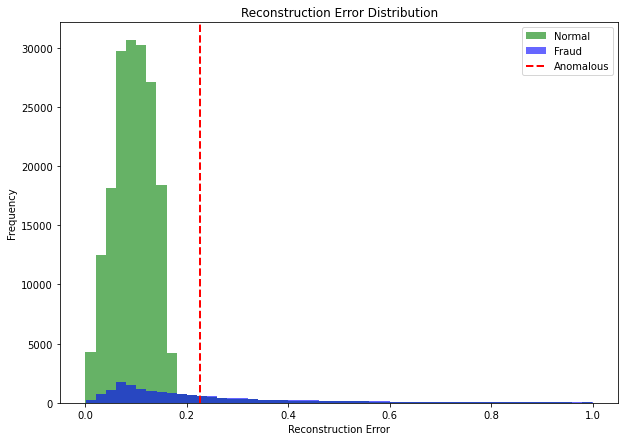

In [99]:
max_val = 1


plt.figure(figsize=(10,7 ))
plt.hist(reconstruction_loss_normal_fraud[reconstruction_loss_normal_fraud < max_val],
         bins=50, alpha=0.6, color='g', label='Normal')
plt.hist(reconstruction_loss_anomalous_fraud[reconstruction_loss_anomalous_fraud < max_val],
         bins=50, alpha=0.6, color='b', label='Fraud')
plt.axvline(x=np.mean(reconstruction_loss_anomalous_fraud[reconstruction_loss_anomalous_fraud < max_val]), 
            color='r', linestyle='dashed', linewidth=2, label='Anomalous')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Run on a cyber security dataset

### Data

In [5]:
dir_data = os.getcwd() + '/data'
os.chdir(dir_data + '/cybersecurity/archive/')

data1 = pd.read_csv('labeled_training_data.csv')
print('train:', data1.shape)
data2 = pd.read_csv('labeled_testing_data.csv')
print('test:', data2.shape)
val_data = pd.read_csv('labeled_validation_data.csv')
print('val:', val_data.shape)

train: (763144, 16)
test: (188967, 16)
val: (188967, 16)


In [6]:
import glob

# 1. Get all CSVs from dataset folder, excluding DNS logs
all_csvs = glob.glob(f"{dir_data}/cybersecurity/archive/*.csv")
csv_files = [f for f in all_csvs if '-dns' not in f]

# 2. Load and combine all selected files
data = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

In [7]:
# 3. Rename the 'evil' column to 'Label' (this is your ground truth)
data.rename(columns={'evil': 'Label'}, inplace=True)

# 4. Confirm basic stats
print(f"Total rows: {len(data)}")
print("Columns:", data.columns.tolist())
print("Class distribution:\n", data['Label'].value_counts())

Total rows: 3807196
Columns: ['timestamp', 'processId', 'parentProcessId', 'userId', 'processName', 'hostName', 'eventId', 'eventName', 'argsNum', 'returnValue', 'args', 'sus', 'Label', 'threadId', 'mountNamespace', 'stackAddresses']
Class distribution:
 Label
0    3638759
1     168437
Name: count, dtype: int64


In [12]:
drop_cols = ['timestamp', 'processName', 'hostName', 'eventName', 'stackAddresses', 'args']
existing_cols = [col for col in drop_cols if col in data.columns]
data = data.drop(columns=existing_cols)

# 2. Separate features and labels
X = data.drop(columns=['Label']).values
y = data['Label'].values

# 3. Train-validation split (80-20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# 5. Oversample attack class
ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

In [13]:
from collections import Counter
print(Counter(y_train_balanced))

Counter({0: 2911006, 1: 2911006})


#### Filter to only non-attacks

In [14]:
# 1. Use only samples from the training data that were not an attack, based on labels
X_benign = X_train[y_train == 0]

# 2. scale the columns
scaler_ae = StandardScaler()
X_benign_scaled = scaler_ae.fit_transform(X_benign)
X_val_scaled = scaler_ae.transform(X_val)

# 3. clean data 
X_benign_scaled = np.nan_to_num(X_benign_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# 1. Autoencoder

### Build Autoencoder model

In [201]:
# Build the AutoEncoder model
attack_model = keras.Sequential([
    # Encoder: Reduce dimensionality, learn the most important features
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Reducing dimension to 64
    keras.layers.Dense(32, activation='relu'), # Further reducing dimension to 32

    # Decoder: Reconstruct the dataset from the reduced representation
    keras.layers.Dense(32, activation='relu'), # Start expanding dimension
    keras.layers.Dense(64, activation='relu'), # Continue expanding dimension
    keras.layers.Dense(X_train.shape[1]) # Restore to original array size ###### don't use sigmoid for the anomaly training
])

custom_optimizer = keras.optimizers.Adam(learning_rate = 0.001)
attack_model.compile(optimizer=custom_optimizer, loss='mse') 

In [203]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

earlystopping = EarlyStopping(monitor='val_loss',
                              min_delta = 0, 
                              patience = 2, 
                              verbose = 1,
                              restore_best_weights=True)

callbacks = [earlystopping]

### Run 

In [204]:
# Train the model
history = attack_model.fit(X_benign_scaled, X_benign_scaled, epochs=10, batch_size=64, validation_data=(X_val_scaled, X_val_scaled), 
                          callbacks = callbacks)

Epoch 1/10
45485/45485 ━━━━━━━━━━━━━━━━━━━━ 73s 2ms/step - loss: 4.0352e-04 - val_loss: 0.0016
Epoch 2/10
45485/45485 ━━━━━━━━━━━━━━━━━━━━ 73s 2ms/step - loss: 3.6811e-04 - val_loss: 0.0018
Epoch 3/10
45485/45485 ━━━━━━━━━━━━━━━━━━━━ 73s 2ms/step - loss: 2.8213e-04 - val_loss: 8.2293e-04
Epoch 4/10
45485/45485 ━━━━━━━━━━━━━━━━━━━━ 73s 2ms/step - loss: 2.8958e-04 - val_loss: 0.0025
Epoch 5/10
45485/45485 ━━━━━━━━━━━━━━━━━━━━ 73s 2ms/step - loss: 2.3018e-04 - val_loss: 0.0023
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


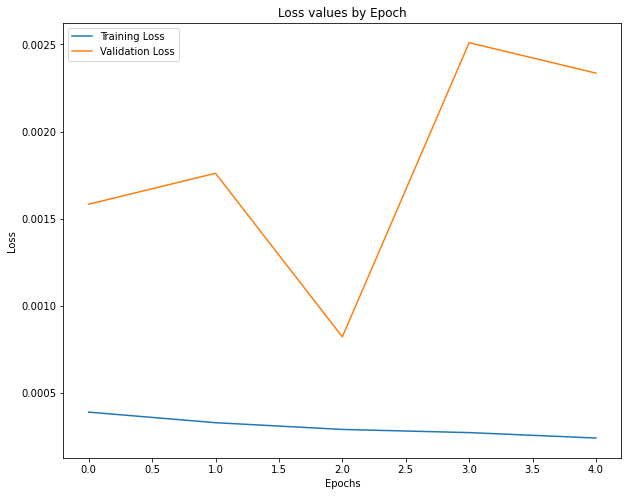

In [205]:
plt.figure(figsize=(10,8))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss values by Epoch")
plt.show()

### Evaluate

In [207]:
from tensorflow.keras.losses import mae
from tensorflow.keras.metrics import Mean

#### Reconstructions dataframe

In [209]:
#### ### I should set aside a hold out validation dataset
reconstructions = attack_model.predict(X_val_scaled, verbose = 0)
reconstruction_error = mae(reconstructions, X_val_scaled)

In [210]:
reconstructions_df = pd.DataFrame({'error': reconstruction_error, 'y_true': y_val}).reset_index(drop = True)
reconstructions_df.head()

,error,y_true
0,0.002469,0
1,0.001667,0
2,0.001552,0
3,0.105081,1
4,0.002550,0


#### Compute the optimal threshold for reconstruction

In [15]:
def threshold_tuning(df, iterations):
    
    threshold_df = {'threshold': [],
                    'accuracy': [],
                    'precision': [],
                    'recall': []}
    
    for i in range(iterations):
        threshold_value = df['error'].quantile(i/iterations)
        preds = df['error'] > threshold_value
        class_report = classification_report(df['y_true'], preds, output_dict=True)
        accuracy = class_report['accuracy']
        precision = class_report['macro avg']['precision']
        recall = class_report['macro avg']['recall']
        
        threshold_df['threshold'].append(threshold_value)
        threshold_df['accuracy'].append(accuracy)
        threshold_df['precision'].append(precision)
        threshold_df['recall'].append(recall)
        
        print(f"Threshold: {threshold_value:.4f}\tAccuracy: {accuracy:.3f}\t\tPrecision: {precision:.3f}\tRecall Score: {recall:.3f}")
        
    return pd.DataFrame(threshold_df)

In [212]:
threshold_df = threshold_tuning(reconstructions_df, 25)

Threshold: 0.0009	Accuracy: 0.044		Precision: 0.522	Recall Score: 0.500
Threshold: 0.0014	Accuracy: 0.084		Precision: 0.523	Recall Score: 0.521
Threshold: 0.0015	Accuracy: 0.124		Precision: 0.524	Recall Score: 0.542
Threshold: 0.0015	Accuracy: 0.164		Precision: 0.525	Recall Score: 0.563
Threshold: 0.0016	Accuracy: 0.204		Precision: 0.526	Recall Score: 0.584
Threshold: 0.0017	Accuracy: 0.244		Precision: 0.528	Recall Score: 0.605
Threshold: 0.0017	Accuracy: 0.284		Precision: 0.529	Recall Score: 0.626
Threshold: 0.0018	Accuracy: 0.324		Precision: 0.531	Recall Score: 0.646
Threshold: 0.0019	Accuracy: 0.364		Precision: 0.533	Recall Score: 0.667
Threshold: 0.0020	Accuracy: 0.404		Precision: 0.535	Recall Score: 0.688
Threshold: 0.0021	Accuracy: 0.444		Precision: 0.537	Recall Score: 0.709
Threshold: 0.0022	Accuracy: 0.484		Precision: 0.540	Recall Score: 0.730
Threshold: 0.0023	Accuracy: 0.524		Precision: 0.543	Recall Score: 0.751
Threshold: 0.0024	Accuracy: 0.564		Precision: 0.546	Recall Score

In [213]:
threshold = threshold_df[threshold_df['recall'] == threshold_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold with Maximum Recall: 0.009425


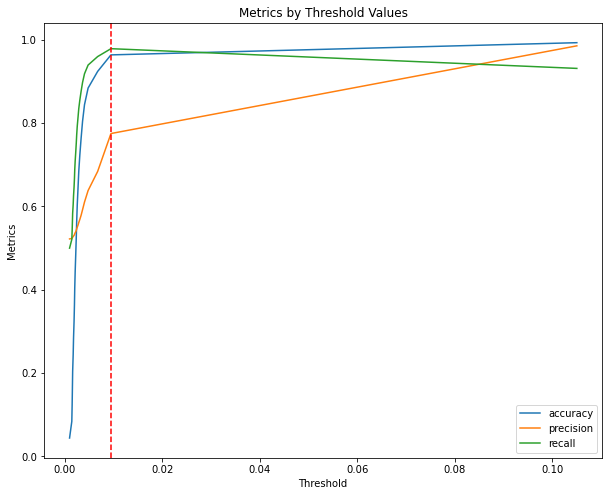

In [214]:
plt.figure(figsize=(10,8))
plt.plot(np.array(threshold_df['threshold']), np.array(threshold_df['accuracy']), label='accuracy')
plt.plot(np.array(threshold_df['threshold']), np.array(threshold_df['precision']), label='precision')
plt.plot(np.array(threshold_df['threshold']), np.array(threshold_df['recall']), label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

#### Visualize samples of the data with their labels in the scatterplot

In [215]:
3000000*0.001

3000.0

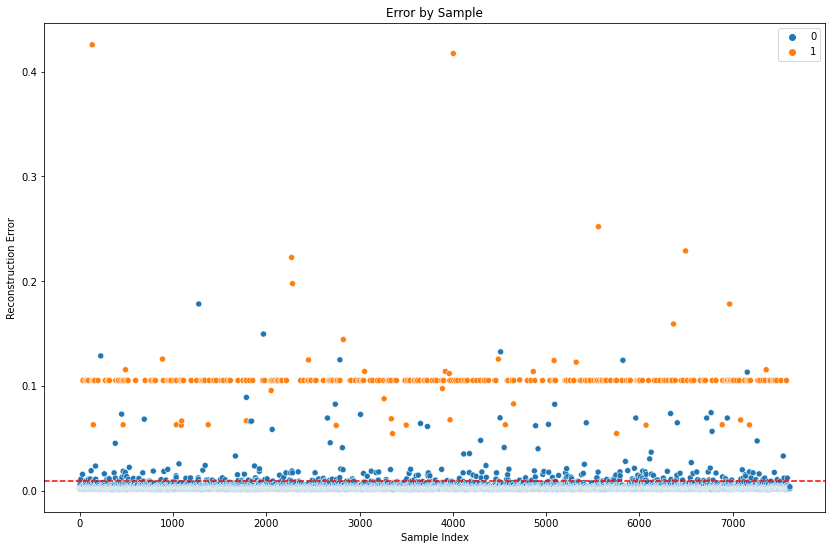

In [216]:
import seaborn as sns

temp = reconstructions_df.sample(frac=0.01, random_state=42).reset_index(drop=True) ## only visualizing 2% of the data
plt.figure(figsize=(14,9))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()

#### Assign Predictions by using the optimal threshold determined above

In [217]:
reconstructions_df['y_pred'] = reconstructions_df['error'] > threshold
reconstructions_df.head()

,error,y_true,y_pred
0,0.002469,0,False
1,0.001667,0,False
2,0.001552,0,False
3,0.105081,1,True
4,0.002550,0,False


#### Examine key metrics using classification report and confusion matrix

In [218]:
print(classification_report(reconstructions_df['y_true'], reconstructions_df['y_pred']))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98    727753
           1       0.55      1.00      0.71     33687

    accuracy                           0.96    761440
   macro avg       0.78      0.98      0.84    761440
weighted avg       0.98      0.96      0.97    761440



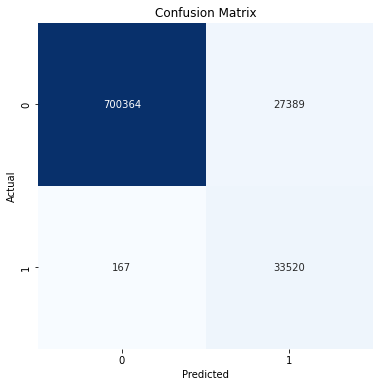

In [219]:
cm = confusion_matrix(reconstructions_df['y_true'],reconstructions_df['y_pred'])
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, cmap='Blues', cbar=False, fmt='.6g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [220]:
print(f"Recall Score: {recall_score(reconstructions_df['y_true'],reconstructions_df['y_pred'])*100:.3f}%")
print(f"Accuracy Score: {accuracy_score(reconstructions_df['y_true'],reconstructions_df['y_pred'])*100:.3f}%")

Recall Score: 99.504%
Accuracy Score: 96.381%


We have a recall score of 99.5 which is excellent. Depending on many factors - risk tolerance, resources available, time, etc - we could re-run with different autoencoder architectures, activation functions, or hyperparameters. 

## Using Results! 

Most important step

Now that we implemented an effective model, we can deploy the model to automate attack responses. To support the organization's response to potential attacks, we can use the error scores for each data point as a guide to prioritize efforts. All of the below should be done **in collaboration with a domain (cybersecurity) expert.**

- We may want to adjust our threshold based on what the error scores are that are on the edge between each label. These may warrant deeper inspection with other ML modeling or human intervention. 
- For the outliers - the error scores that are most significant and furthest in the 'attack' category - we can probably triage differently and treat these observations as attacks with no further verification steps. This will save significant time and resources for the humans.
- We can conduct exploratory analysis to compare each variable's distribution for the 'attack' class against the 'non-attack' class. This could be especially useful in understanding feature importance, or for triaging those observations with borderline error scores.

# Gaussian Mixture Model (GMM) 

- Probabilistic clustering, great for unlabeled cyber network data

## Data

In [18]:
X_benign_scaled.shape

(2911006, 9)

In [20]:
X_benign_scaled[:3]

array([[ 0.29310357, -0.55253651, -0.08054318,  1.74474845,  0.97182368,
        -0.05364965, -0.29277261,  0.        ,  0.        ],
       [ 0.25372778,  1.47934898, -0.08054318, -0.133245  ,  0.97182368,
        -0.02867508, -0.29277261,  0.        ,  0.        ],
       [ 0.26832779, -0.55253651, -0.08054318,  1.74474845,  0.97182368,
        -0.05364965, -0.29277261,  0.        ,  0.        ]])

In [109]:
######## should be using data from BOTH classes

X_train.shape ### unbalanced data - let's see how it does

(3045756, 9)

In [112]:
X_train_clean = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)

## Implement the GMM model

In [114]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib

print("Started:")
print_time()

gmm = GaussianMixture(n_components=2)
#gmm.fit(X_benign_scaled)
gmm.fit(X_train_clean)

print("end:")
print_time()

Started:
10/3/2026 at 1:7:54 am in (hr:min:sec)
end:
10/3/2026 at 1:8:28 am in (hr:min:sec)


## Options to optimize - skip for now until seeing initial results.

## Get labels and predicted probabilities using the desired/optimized model

In [115]:
X_train_clean.shape

(3045756, 9)

In [116]:
#### was using X_benign_scaled, but that was under the assumption that we have labeled data: attack vs non-attack
print("Started:")
print_time()

print("assigning labels...")
labels = gmm.predict(X_train_clean)
print(f'Labels: {len(labels)}\n')

print("assigning probabilities...")
probs = gmm.predict_proba(X_train_clean)
print(f'Probabilities: {len(probs)}\n')

print("end:")
print_time()

Started:
10/3/2026 at 1:9:2 am in (hr:min:sec)
assigning labels...
Labels: 3045756

assigning probabilities...
Probabilities: 3045756

end:
10/3/2026 at 1:9:6 am in (hr:min:sec)


## Examine results

### Get results into a dataframe with original x-features

In [117]:
X_train_clean[:2]

array([[ 0.28675016, -0.59996405, -0.22770499,  1.7929152 ,  0.98241023,
        -0.04158005, -0.36874572,  0.        ,  0.        ],
       [ 0.24654315,  1.37755885, -0.22770499, -0.10699915,  0.98241023,
        -0.01649801, -0.36874572,  0.        ,  0.        ]])

In [151]:
res_df = pd.DataFrame(X_train_clean, columns = data.drop(columns=['Label']).columns)

res_df['label'] = labels
res_df = res_df.reset_index(drop = False)

# probabilities
res_probs = pd.DataFrame(probs)
res_probs.columns = [f'probs_{col}' for col in res_probs.columns]
res_probs['prob_label'] = res_probs.max(axis=1)
res_probs = res_probs.reset_index(drop = False)

res_df = res_df.merge(res_probs, how = 'left', on = 'index')

# colors
color_df = {0: 'steelblue', 1: 'tan', 2: 'green'} # back up colors for more clusters
res_df['color'] = res_df['label'].apply(lambda x: color_df[x])

In [152]:
res_df

,index,processId,parentProcessId,userId,eventId,argsNum,returnValue,sus,threadId,mountNamespace,label,probs_0,probs_1,prob_label,color
0,0,0.286750,-0.599964,-0.227705,1.792915,0.982410,-0.041580,-0.368746,0.000000,0.000000,0,1.0,9.798116e-17,1.0,steelblue
1,1,0.246543,1.377559,-0.227705,-0.106999,0.982410,-0.016498,-0.368746,0.000000,0.000000,0,1.0,1.028795e-12,1.0,steelblue
2,2,0.261451,-0.599964,-0.227705,1.792915,0.982410,-0.041580,-0.368746,0.000000,0.000000,0,1.0,1.241595e-16,1.0,steelblue
3,3,0.623315,1.701999,0.271895,-0.752157,-1.297746,-0.041580,2.711896,0.000000,0.000000,1,0.0,1.000000e+00,1.0,tan
4,4,0.133602,-0.941309,-0.227705,-0.747077,-0.537694,-0.041580,-0.368746,0.188732,1.531398,0,1.0,4.003670e-28,1.0,steelblue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3045751,3045751,0.417762,1.382760,-0.227705,-0.675957,-0.537694,-0.036006,-0.368746,0.000000,0.000000,0,1.0,3.332586e-13,1.0,steelblue
3045752,3045752,0.136313,-0.941309,-0.227705,-0.538798,-1.297746,-0.047154,-0.368746,0.192051,1.531398,0,1.0,6.596123e-28,1.0,steelblue
3045753,3045753,0.187814,1.383085,-0.227705,1.792915,0.982410,-0.041580,-0.368746,0.000000,0.000000,0,1.0,3.507329e-13,1.0,steelblue
3045754,3045754,0.178779,-0.565179,-0.227705,-0.106999,0.982410,-0.016498,-0.368746,0.000000,0.000000,0,1.0,7.009994e-16,1.0,steelblue


In [120]:
res_df.prob_label.describe()

count    3.045756e+06
mean     9.999939e-01
std      9.066164e-04
min      5.694146e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: prob_label, dtype: float64

In [121]:
inspect_threshold = 0.99

In [122]:
#### get subset of the dataframe for further inspection
res_df_subset = res_df[res_df['prob_label'] < inspect_threshold]
res_df_subset

,index,processId,parentProcessId,userId,eventId,argsNum,returnValue,sus,threadId,mountNamespace,label,probs_0,probs_1,prob_label,color
3126,3126,-2.913096,-1.001775,-0.227705,-0.106999,0.98241,0.019732,-0.368746,0.0,0.0,0,0.986054,0.013946,0.986054,steelblue
21903,21903,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan
23751,23751,-3.143044,-1.002100,-0.227705,-0.028259,0.98241,0.019732,-0.368746,0.0,0.0,0,0.967420,0.032580,0.967420,steelblue
33107,33107,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan
143353,143353,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970496,2970496,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.019732,-0.368746,0.0,0.0,0,0.975353,0.024647,0.975353,steelblue
3000672,3000672,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan
3010492,3010492,-3.143044,-1.002100,-0.227705,-0.028259,0.98241,0.022519,-0.368746,0.0,0.0,0,0.833486,0.166514,0.833486,steelblue
3012358,3012358,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan


In [158]:
preserve = res_df.copy()

In [156]:
# edge styling
res_df['edge_color'] = res_df.apply(lambda x: 'red' if (x.prob_label < inspect_threshold) 
                                    else 'black', axis = 1)
res_df['edge_width'] = res_df.apply(lambda x: 1.5 if (x.prob_label < inspect_threshold) 
                                    else 0.7, axis = 1)

In [160]:
res_df

,index,processId,parentProcessId,userId,eventId,argsNum,returnValue,sus,threadId,mountNamespace,label,probs_0,probs_1,prob_label,color,edge_color,edge_width
0,0,0.286750,-0.599964,-0.227705,1.792915,0.982410,-0.041580,-0.368746,0.000000,0.000000,0,1.0,9.798116e-17,1.0,steelblue,black,0.7
1,1,0.246543,1.377559,-0.227705,-0.106999,0.982410,-0.016498,-0.368746,0.000000,0.000000,0,1.0,1.028795e-12,1.0,steelblue,black,0.7
2,2,0.261451,-0.599964,-0.227705,1.792915,0.982410,-0.041580,-0.368746,0.000000,0.000000,0,1.0,1.241595e-16,1.0,steelblue,black,0.7
3,3,0.623315,1.701999,0.271895,-0.752157,-1.297746,-0.041580,2.711896,0.000000,0.000000,1,0.0,1.000000e+00,1.0,tan,black,0.7
4,4,0.133602,-0.941309,-0.227705,-0.747077,-0.537694,-0.041580,-0.368746,0.188732,1.531398,0,1.0,4.003670e-28,1.0,steelblue,black,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3045751,3045751,0.417762,1.382760,-0.227705,-0.675957,-0.537694,-0.036006,-0.368746,0.000000,0.000000,0,1.0,3.332586e-13,1.0,steelblue,black,0.7
3045752,3045752,0.136313,-0.941309,-0.227705,-0.538798,-1.297746,-0.047154,-0.368746,0.192051,1.531398,0,1.0,6.596123e-28,1.0,steelblue,black,0.7
3045753,3045753,0.187814,1.383085,-0.227705,1.792915,0.982410,-0.041580,-0.368746,0.000000,0.000000,0,1.0,3.507329e-13,1.0,steelblue,black,0.7
3045754,3045754,0.178779,-0.565179,-0.227705,-0.106999,0.982410,-0.016498,-0.368746,0.000000,0.000000,0,1.0,7.009994e-16,1.0,steelblue,black,0.7


In [162]:
res_df['true_label'] = y_train

In [163]:
#### get subset of the dataframe for further inspection
res_df_subset = res_df[res_df['prob_label'] < inspect_threshold]
res_df_subset

,index,processId,parentProcessId,userId,eventId,argsNum,returnValue,sus,threadId,mountNamespace,label,probs_0,probs_1,prob_label,color,edge_color,edge_width,true_label
3126,3126,-2.913096,-1.001775,-0.227705,-0.106999,0.98241,0.019732,-0.368746,0.0,0.0,0,0.986054,0.013946,0.986054,steelblue,red,1.5,0
21903,21903,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan,red,1.5,0
23751,23751,-3.143044,-1.002100,-0.227705,-0.028259,0.98241,0.019732,-0.368746,0.0,0.0,0,0.967420,0.032580,0.967420,steelblue,red,1.5,0
33107,33107,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan,red,1.5,0
143353,143353,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan,red,1.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970496,2970496,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.019732,-0.368746,0.0,0.0,0,0.975353,0.024647,0.975353,steelblue,red,1.5,0
3000672,3000672,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan,red,1.5,0
3010492,3010492,-3.143044,-1.002100,-0.227705,-0.028259,0.98241,0.022519,-0.368746,0.0,0.0,0,0.833486,0.166514,0.833486,steelblue,red,1.5,0
3012358,3012358,-3.143044,-1.002100,-0.227705,-0.106999,0.98241,0.028092,-0.368746,0.0,0.0,1,0.127709,0.872291,0.872291,tan,red,1.5,0


### Inspect recall, precision, accuracy

We typically wouldn't have this, but just for a gauge of how accurate these probabilities are 

In [165]:
print(classification_report(res_df['true_label'], res_df['label']))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95   2911006
           1       0.31      1.00      0.48    134750

    accuracy                           0.90   3045756
   macro avg       0.66      0.95      0.71   3045756
weighted avg       0.97      0.90      0.93   3045756



**Results**

Recall is good!! We can see that the clusters below do make sense. But we just wanted to get a good gauge, since we have labeled data.

We will need to examine, however, (1) how many false positives we have and whether this is realistic given resources, (2) if we can lower the threshold at all while keeping recall at 100%, because maybe the model is a little too sensitive.

### Histogram of the range of resulting probabilities

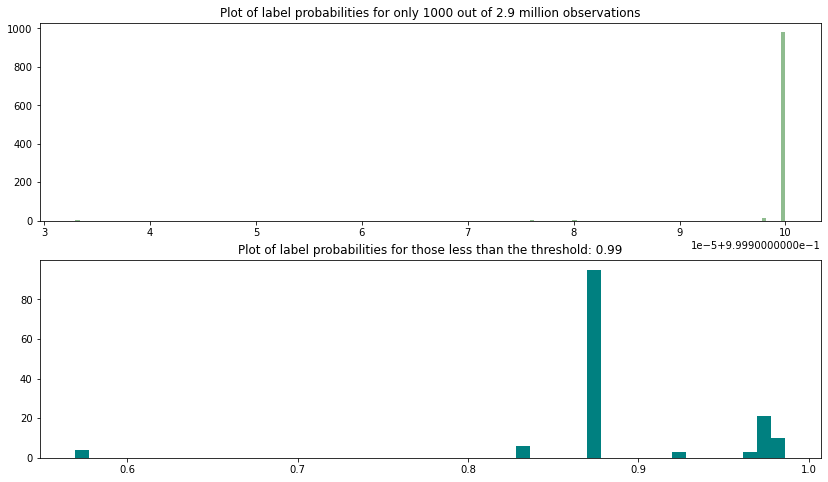

In [166]:
fig, ax = plt.subplots(2, figsize = (14, 8))
ax[0].hist(res_df[:1000].prob_label, bins = 150, color = 'darkseagreen')
ax[0].set_title('Plot of label probabilities for only 1000 out of 2.9 million observations')
ax[1].hist(res_df_subset.prob_label, bins = 50, color = 'teal')
ax[1].set_title(f'Plot of label probabilities for those less than the threshold: {inspect_threshold}')
fig.show()

### Scatterplot of original datapoints with their labels and "edge-case" probabilities 

#### Need dimension reduction first

In [98]:
from sklearn.manifold import TSNE

In [106]:
res_df.label.value_counts()

label
0    2612773
1     298233
Name: count, dtype: int64

In [142]:
df_scatter0 = res_df[res_df.label == 0].sample(frac=0.005, random_state=42).reset_index(drop=True)
df_scatter1 = res_df[res_df.label == 1].sample(frac=0.005, random_state=42).reset_index(drop=True)
df_scatter = pd.concat([res_df_subset, df_scatter0])
df_scatter = pd.concat([df_scatter, df_scatter1])
df_scatter

,index,processId,parentProcessId,userId,eventId,argsNum,returnValue,sus,threadId,mountNamespace,label,probs_0,probs_1,prob_label,color,edge_color,edge_width
3126,3126,-2.913096,-1.001775,-0.227705,-0.106999,0.982410,0.019732,-0.368746,0.000000,0.000000,0,9.860540e-01,0.013946,0.986054,steelblue,red,1.5
21903,21903,-3.143044,-1.002100,-0.227705,-0.106999,0.982410,0.028092,-0.368746,0.000000,0.000000,1,1.277092e-01,0.872291,0.872291,tan,red,1.5
23751,23751,-3.143044,-1.002100,-0.227705,-0.028259,0.982410,0.019732,-0.368746,0.000000,0.000000,0,9.674198e-01,0.032580,0.967420,steelblue,red,1.5
33107,33107,-3.143044,-1.002100,-0.227705,-0.106999,0.982410,0.028092,-0.368746,0.000000,0.000000,1,1.277092e-01,0.872291,0.872291,tan,red,1.5
143353,143353,-3.143044,-1.002100,-0.227705,-0.106999,0.982410,0.028092,-0.368746,0.000000,0.000000,1,1.277092e-01,0.872291,0.872291,tan,red,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2137,2402785,-3.059016,-1.001775,-0.227705,-0.617538,1.742462,20.341759,-0.368746,-3.720206,1.531398,1,0.000000e+00,1.000000,1.000000,tan,black,0.7
2138,1125984,0.478298,1.305714,-0.227705,-0.747077,-0.537694,-0.041580,2.711896,0.000000,0.000000,1,0.000000e+00,1.000000,1.000000,tan,black,0.7
2139,1980584,0.560068,1.662663,0.271895,1.792915,0.982410,-0.041580,2.711896,0.000000,0.000000,1,0.000000e+00,1.000000,1.000000,tan,black,0.7
2140,137787,-2.918065,-1.001775,-0.227705,-0.208599,0.222358,0.203667,-0.368746,-3.547631,1.942520,1,1.450133e-148,1.000000,1.000000,tan,black,0.7


#### 2D Scatter plot (static)

In [143]:
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(df_scatter[df_scatter.columns[1:10]])

# implement venv and work out dependencies -> then use UMAP instead of TSNE
#X_benign_scaled_reduced = umap.UMAP(n_components = 2, min_dist = 0.0, metric = 'cosine', random_state = 42).fit_transform(res_df[:1000])

In [144]:
X_reduced_scatter = pd.DataFrame(X_reduced, columns = ['x', 'y'])
X_reduced_scatter['label'] = list(df_scatter['label'])
X_reduced_scatter['color'] = list(df_scatter['color'])
X_reduced_scatter['edge_color'] = list(df_scatter['edge_color'])
X_reduced_scatter['edge_width'] = list(df_scatter['edge_width'])

In [192]:
def examine_scatter_2d(df):
    fig, ax = plt.subplots(figsize = (18, 10))

    legend_handles, legend_labels = [], []
    for label in df.label.unique():
        temp = df[df.label == label]
        ax.scatter(temp.x, temp.y, c = temp.color, label = label, edgecolors = temp.edge_color, 
                   lw = temp.edge_width, s = 100)
        rect = matplotlib.patches.Rectangle((0, 0), width = 0.7, height = 0.8, fc = list(temp.color.unique())[0], # should only be one -- refactor
                            lw = 0.5, ec = list(temp.color.unique())[0])
        legend_handles.append(rect)
        legend_labels.append(label)

    # add marker for the edgecolor
    legend_handles.append(matplotlib.patches.Rectangle((0,0), width = 0.7, height = 0.8, fc = 'whitesmoke', lw = 2, ec = 'red'))
    legend_labels.append(f'Prob < {inspect_threshold}')

    plt.legend(legend_handles, legend_labels)
    ax.set_facecolor('whitesmoke')
    ax.set_title('TSNE-reduced Plot of Probabilistic Clusters - sample of 15,000 data points (~0.5%)\n')

    plt.show()

In [189]:
15000 * 100

1500000

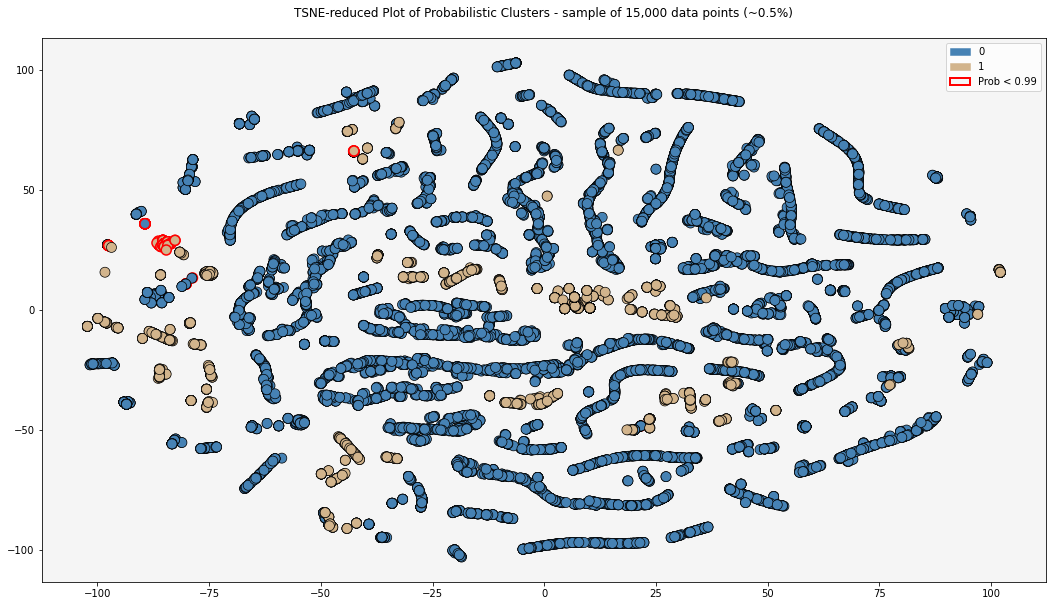

In [193]:
examine_scatter_2d(X_reduced_scatter)

#### 3D scatter plot (dynamic!)

In [196]:
res_df.head()

,index,processId,parentProcessId,userId,eventId,argsNum,returnValue,sus,threadId,mountNamespace,label,probs_0,probs_1,prob_label,color,edge_color,edge_width,true_label
0,0,0.286750,-0.599964,-0.227705,1.792915,0.982410,-0.041580,-0.368746,0.000000,0.000000,0,1.0,9.798116e-17,1.0,steelblue,black,0.7,0
1,1,0.246543,1.377559,-0.227705,-0.106999,0.982410,-0.016498,-0.368746,0.000000,0.000000,0,1.0,1.028795e-12,1.0,steelblue,black,0.7,0
2,2,0.261451,-0.599964,-0.227705,1.792915,0.982410,-0.041580,-0.368746,0.000000,0.000000,0,1.0,1.241595e-16,1.0,steelblue,black,0.7,0
3,3,0.623315,1.701999,0.271895,-0.752157,-1.297746,-0.041580,2.711896,0.000000,0.000000,1,0.0,1.000000e+00,1.0,tan,black,0.7,0
4,4,0.133602,-0.941309,-0.227705,-0.747077,-0.537694,-0.041580,-0.368746,0.188732,1.531398,0,1.0,4.003670e-28,1.0,steelblue,black,0.7,0


In [167]:
tsne_3d = TSNE(n_components=3, random_state=42)
X_reduced_3d = tsne_3d.fit_transform(df_scatter[df_scatter.columns[1:10]])

In [195]:
X_reduced_3d[:3]

array([[  5.751191  , -16.22336   ,  -7.092094  ],
       [ 15.692536  , -19.744411  ,   0.22555068],
       [ 17.53833   , -23.921589  ,  -7.3738866 ]], dtype=float32)

In [170]:
X_reduced_scatter_3d = pd.DataFrame(X_reduced_3d, columns = ['x', 'y', 'z'])
X_reduced_scatter_3d['label'] = list(df_scatter['label'])
X_reduced_scatter_3d['color'] = list(df_scatter['color'])
X_reduced_scatter_3d['edge_color'] = list(df_scatter['edge_color'])
X_reduced_scatter_3d['edge_width'] = list(df_scatter['edge_width'])
#X_reduced_scatter_3d['label_probs'] = list(df_scatter['edge_width'])

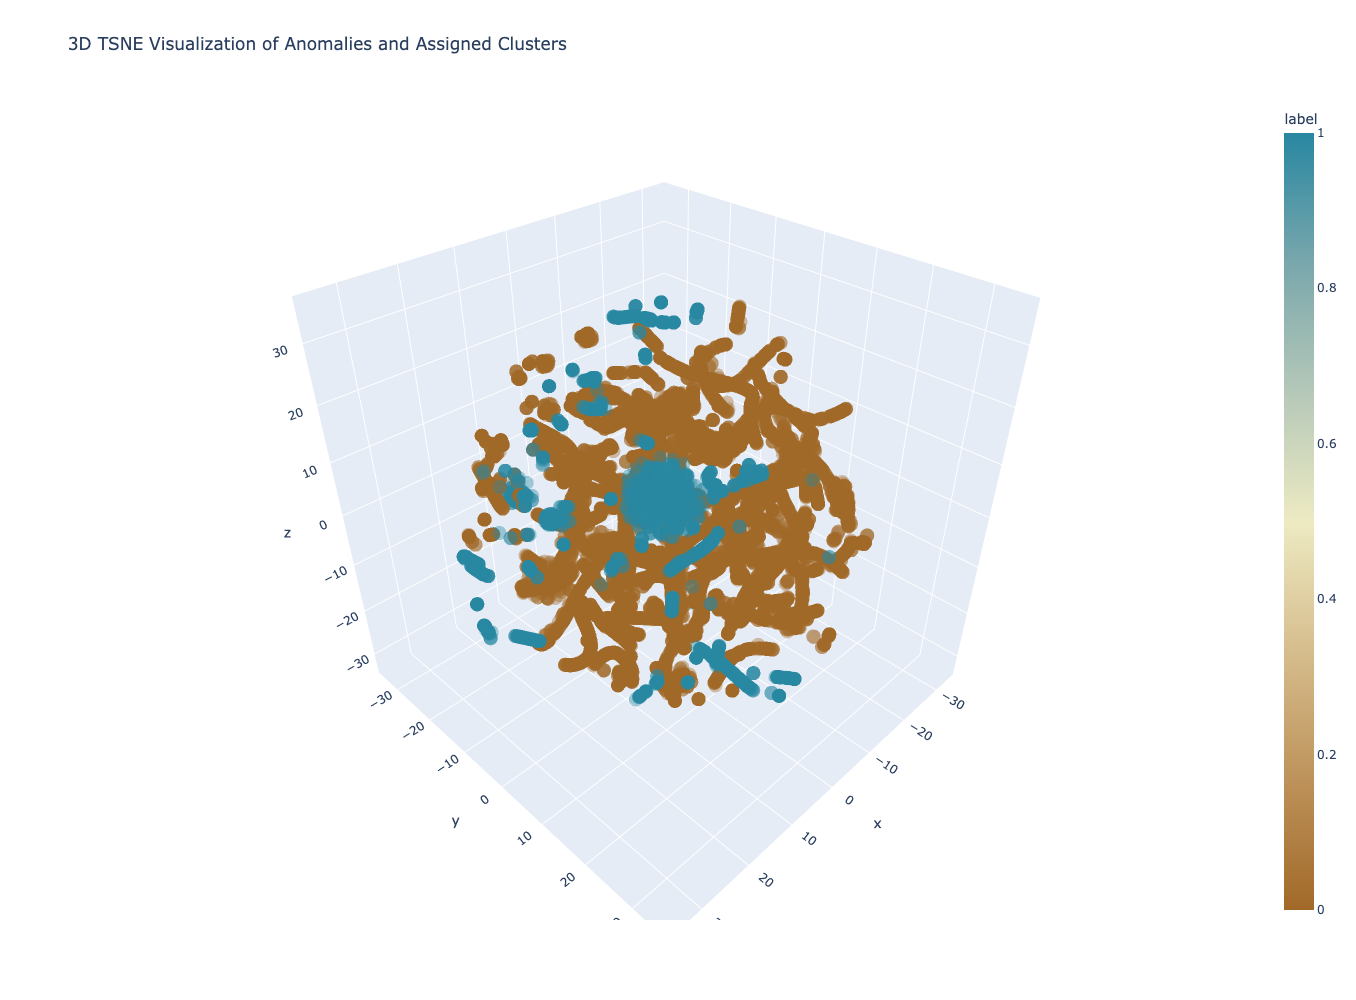

In [188]:
import plotly.express as px
#df_3d = pd.DataFrame(
#   reduced_embeddings_3d,
#   columns=["x", "y", "z"]
#)
#df_3d["title"] = titles
#df_3d["cluster"] = [str(c) for c in clusters]
#df_3d["size"] = 10000

# Create 3D scatter plot 
fig = px.scatter_3d(
                    X_reduced_scatter_3d,
                    x='x',
                    y='y',
                    z='z',
                    color='label',
                    title='3D TSNE Visualization of Anomalies and Assigned Clusters',
                    opacity=0.4,
                    #color_discrete_sequence = ['steelblue', 'tan'], # need to convert to RGBA
                    color_continuous_scale='earth',
                    size_max=0.01,
                    #size = 'size',
                    hover_data=['label']  # Show title on hover
)

# Update layout
fig.update_layout(
   width=900,
   height=1000,
   showlegend=True
)

fig.show()

fig.write_html('3d_anomalyViz_GMM.html')

https://pandas.pydata.org/docs/reference/api/pandas.plotting.parallel_coordinates.html

## Testing the GMM on make moons dataset

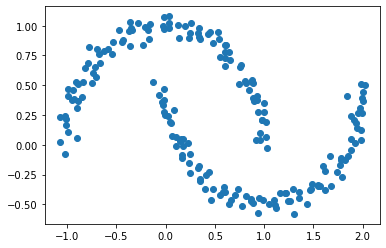

In [24]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
xmoon, ymoon = make_moons(200, noise=0.05, random_state=0)
plt.scatter(xmoon[:,0], xmoon[:,1])

### Fit model

In [41]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib

gmm = GaussianMixture(n_components=2)
gmm.fit(xmoon)

GaussianMixture(n_components=2)

### (option) Optimize using BIC and AIC

- for our use case, we probably only want 2-3 components. We can automate responses by identifying edge data points with relatively lower probabilities, rather than trying to get them to fit perfectly into clusters. This can also support interpretability - much harder to interpret 8 clusters than 2-3.

num components measures how well GMM works as a density estimator, not as a clustering algorithm. GMM Should be used for clustering only for certain datasets, or use cases (in my opinion).

In [28]:
n_components = np.arange(1, 20)
models = [GaussianMixture(n, covariance_type = 'full', random_state = 0).fit(xmoon) for n in n_components]

Text(0.5, 0, 'n_components')

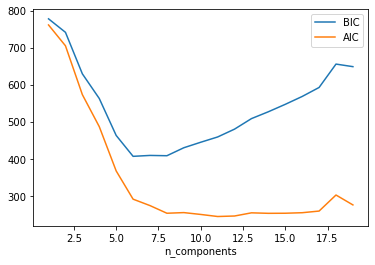

In [29]:
plt.plot(n_components, [model.bic(xmoon) for model in models], label = 'BIC')
plt.plot(n_components, [model.aic(xmoon) for model in models], label = 'AIC')
plt.legend(loc = 'best')
plt.xlabel('n_components')

### (option) re-run GMM with the optimized n_components

### Get labels and predicted probabilities using the desired/optimized model

In [31]:
gmm = GaussianMixture(n_components=2)
gmm.fit(xmoon)

print("assigning labels...")
labels = gmm.predict(xmoon)
print(f'Labels: {len(labels)}\n')

print("assigning probabilities...")
probs = gmm.predict_proba(xmoon)
print(f'Probabilities: {len(probs)}\n')

assigning labels...
Labels: 200

assigning probabilities...
Probabilities: 200



### Examine results

#### Get results into a dataframe with original x-features

In [35]:
inspect_threshold = 0.90

In [57]:
res_df = pd.DataFrame(columns = ['x', 'y', 'label'])
res_df['x'] = xmoon[:,0]
res_df['y'] = xmoon[:,1]
res_df['label'] = labels
res_df = res_df.reset_index(drop = False)

# probabilities
res_probs = pd.DataFrame(probs)
res_probs.columns = [f'probs_{col}' for col in res_probs.columns]
res_probs['prob_label'] = res_probs.max(axis=1)
res_probs = res_probs.reset_index(drop = False)

res_df = res_df.merge(res_probs, how = 'left', on = 'index')

# colors
color_df = {0: 'steelblue', 1: 'tan', 2: 'green'} # back up colors for more clusters
res_df['color'] = res_df['label'].apply(lambda x: color_df[x])

# edge styling
res_df['edge_color'] = res_df.apply(lambda x: 'red' if (x.prob_label < inspect_threshold) 
                                    else 'black', axis = 1)
res_df['edge_width'] = res_df.apply(lambda x: 1.5 if (x.prob_label < inspect_threshold) 
                                    else 0.7, axis = 1)


#### get subset of the dataframe for further inspection
res_df_subset = res_df[res_df['prob_label'] < inspect_threshold]

In [58]:
res_df

,index,x,y,label,probs_0,probs_1,prob_label,color,edge_color,edge_width
0,0,0.816805,0.521645,0,0.744732,0.255268,0.744732,steelblue,red,1.5
1,1,1.618596,-0.379829,1,0.000003,0.999997,0.999997,tan,black,0.7
2,2,-0.021270,0.273728,0,0.941547,0.058453,0.941547,steelblue,black,0.7
3,3,-1.021810,-0.075440,0,0.986275,0.013725,0.986275,steelblue,black,0.7
4,4,1.766546,-0.170699,1,0.000014,0.999986,0.999986,tan,black,0.7
...,...,...,...,...,...,...,...,...,...,...
195,195,-0.536334,0.860268,0,0.999988,0.000012,0.999988,steelblue,black,0.7
196,196,1.882817,0.244356,1,0.000662,0.999338,0.999338,tan,black,0.7
197,197,0.175752,-0.007231,1,0.236888,0.763112,0.763112,tan,red,1.5
198,198,0.124236,1.007902,0,0.999928,0.000072,0.999928,steelblue,black,0.7


#### Histogram of the range of resulting probabilities

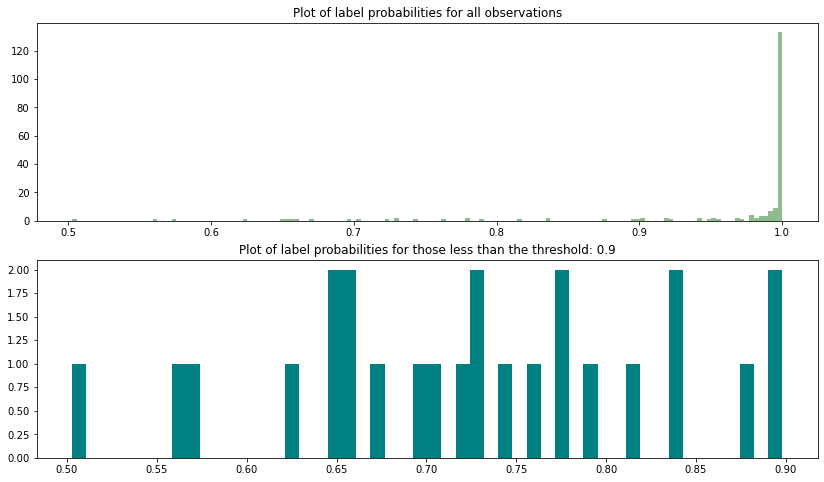

In [40]:
fig, ax = plt.subplots(2, figsize = (14, 8))
ax[0].hist(res_df.prob_label, bins = 150, color = 'darkseagreen')
ax[0].set_title('Plot of label probabilities for all observations')
ax[1].hist(res_df_subset.prob_label, bins = 50, color = 'teal')
ax[1].set_title(f'Plot of label probabilities for those less than the threshold: {inspect_threshold}')
fig.show()

#### Scatterplot of original datapoints with their labels and "edge-case" probabilities 

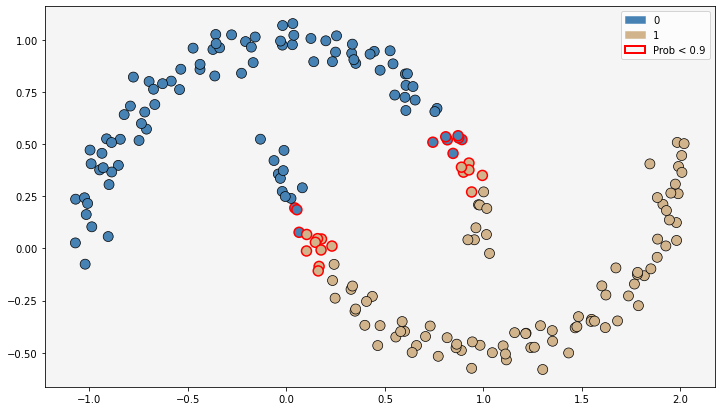

In [61]:
fig, ax = plt.subplots(figsize = (12, 7))

legend_handles, legend_labels = [], []
for label in res_df.label.unique():
    temp = res_df[res_df.label == label]
    ax.scatter(temp.x, temp.y, c = temp.color, label = label, edgecolors = temp.edge_color, 
               lw = temp.edge_width, s = 100)
    rect = matplotlib.patches.Rectangle((0, 0), width = 0.7, height = 0.8, fc = list(temp.color.unique())[0], # should only be one -- refactor
                        lw = 0.5, ec = list(temp.color.unique())[0])
    legend_handles.append(rect)
    legend_labels.append(label)

# add marker for the edgecolor
legend_handles.append(matplotlib.patches.Rectangle((0,0), width = 0.7, height = 0.8, fc = 'whitesmoke', lw = 2, ec = 'red'))
legend_labels.append(f'Prob < {inspect_threshold}')

plt.legend(legend_handles, legend_labels)
ax.set_facecolor('whitesmoke')

plt.show()

In [ ]:
#### we can see how this is not effective at clustering with 2 clusters

## Graph Neural net

https://developer.nvidia.com/blog/applying-autoencoder-based-gnns-for-high-throughput-network-anomaly-detection-in-netflow-data/